# DeepPoly MNIST Robustness Bounds

This notebook is a compact robustness-certification experiment on MNIST. It compares a normally trained multilayer perceptron against the same architecture trained with a DeepPoly-based robustness objective.

**Certification target.** For each test image, we consider all pixel perturbations inside an `L_inf` ball of radius `epsilon`. DeepPoly propagates lower and upper bounds through the network and proves robustness when the true class lower bound is larger than every wrong class upper bound:

`lower[y] > upper[j]` for every `j != y`.

All reported certification results are computed over multiple test images (`CERT_LIMIT`), not a single selected example.


In [ ]:
import gzip
import random
import struct
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = Path("mnist")
BASELINE_MODEL_PATH = Path("mnist_baseline.pt")
ROBUST_MODEL_PATH = Path("mnist_deeppoly_robust.pt")

RESET_MODELS = True  # set False after one full run to reuse saved weights

EPSILON = 0.05
EVAL_EPSILONS = [0.00, 0.01, 0.03, 0.05]

TRAIN_LIMIT = 12000
ROBUST_TRAIN_LIMIT = 12000
CERT_LIMIT = 100  # number of correctly-classified images per model to certify

BASELINE_EPOCHS = 8
ROBUST_EPOCHS = 12
BASELINE_BATCH = 128
ROBUST_BATCH = 32
BASELINE_LR = 1e-3
ROBUST_LR = 5e-4
ROBUST_LAMBDA = 0.12

print(f"device={DEVICE}")

device=cpu


In [ ]:
BASE_URL = "https://ossci-datasets.s3.amazonaws.com/mnist"
MNIST_FILES = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz",
]


def ensure_mnist(data_dir=DATA_DIR):
    data_dir.mkdir(exist_ok=True)
    for filename in MNIST_FILES:
        raw_path = data_dir / filename[:-3]
        gz_path = data_dir / filename
        if raw_path.exists():
            continue

        print(f"downloading {filename}")
        urllib.request.urlretrieve(f"{BASE_URL}/{filename}", gz_path)
        with gzip.open(gz_path, "rb") as src, open(raw_path, "wb") as dst:
            dst.write(src.read())
        gz_path.unlink()


def read_images(path):
    with open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"bad image file: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows * cols).astype(np.float32) / 255.0


def read_labels(path):
    with open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"bad label file: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.astype(np.int64)


def load_mnist(data_dir=DATA_DIR):
    ensure_mnist(data_dir)
    x_train = read_images(data_dir / "train-images-idx3-ubyte")
    y_train = read_labels(data_dir / "train-labels-idx1-ubyte")
    x_test = read_images(data_dir / "t10k-images-idx3-ubyte")
    y_test = read_labels(data_dir / "t10k-labels-idx1-ubyte")

    x_train = torch.from_numpy(x_train).to(DEVICE)
    y_train = torch.from_numpy(y_train).to(DEVICE)
    x_test = torch.from_numpy(x_test).to(DEVICE)
    y_test = torch.from_numpy(y_test).to(DEVICE)
    return x_train, y_train, x_test, y_test


X_train, y_train, X_test, y_test = load_mnist()
print(f"train={tuple(X_train.shape)}  test={tuple(X_test.shape)}")

downloading train-images-idx3-ubyte.gz
downloading train-labels-idx1-ubyte.gz
downloading t10k-images-idx3-ubyte.gz
downloading t10k-labels-idx1-ubyte.gz
train=(60000, 784)  test=(10000, 784)


In [ ]:
class MLP(nn.Module):
    """
    Three-layer fully-connected classifier for MNIST.
    Input: 784-dim flattened pixel vector (values in [0, 1]).
    Architecture: Linear(784→64) → ReLU → Linear(64→32) → ReLU → Linear(32→10).
    Output: unnormalised logits for 10 digit classes.
    Kept intentionally small so DeepPoly abstract interpretation stays tractable.
    """
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.layers(x)


def batched_indices(n, batch_size, shuffle=True):
    if shuffle:
        order = torch.randperm(n, device=DEVICE)
    else:
        order = torch.arange(n, device=DEVICE)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


@torch.no_grad()
def clean_accuracy(model, x, y, limit=None, batch_size=512):
    """Returns fraction of correctly classified examples (no perturbation)."""
    model.eval()
    if limit is not None:
        x = x[:limit]
        y = y[:limit]
    correct = 0
    total = 0
    for idx in batched_indices(len(x), batch_size, shuffle=False):
        pred = model(x[idx]).argmax(dim=1)
        correct += (pred == y[idx]).sum().item()
        total += len(idx)
    return correct / total


def train_clean(model, x, y, epochs, batch_size, lr, limit):
    """Standard cross-entropy training loop with per-epoch test accuracy logging."""
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    x = x[:limit]
    y = y[:limit]

    for epoch in range(1, epochs + 1):
        losses = []
        model.train()
        for idx in batched_indices(len(x), batch_size, shuffle=True):
            logits = model(x[idx])
            loss = F.cross_entropy(logits, y[idx])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        acc = clean_accuracy(model, X_test, y_test, limit=1000)
        print(f"clean epoch {epoch:02d}/{epochs}  loss={np.mean(losses):.4f}  test_acc_1k={100 * acc:.2f}%")


def save_model(model, path):
    torch.save(model.state_dict(), path)


def load_model(path):
    model = MLP().to(DEVICE)
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)
    return model

In [ ]:
def eval_symbolic(lb_coef, ub_coef, lb_bias, ub_bias, inp_l, inp_u):
    """
    Concretises symbolic affine bounds into concrete interval bounds.
    Each neuron's bound is an affine function of the original input box [inp_l, inp_u].
    lb_coef/ub_coef: (batch, neurons_out, neurons_in) — coefficient matrices.
    lb_bias/ub_bias: (batch, neurons_out) — constant terms.
    Returns concrete lower and upper bounds of shape (batch, neurons_out).
    """
    lower = lb_bias + torch.where(lb_coef >= 0, lb_coef * inp_l[:, None, :], lb_coef * inp_u[:, None, :]).sum(dim=2)
    upper = ub_bias + torch.where(ub_coef >= 0, ub_coef * inp_u[:, None, :], ub_coef * inp_l[:, None, :]).sum(dim=2)
    return lower, upper


def dp_first_linear(layer, inp_l, inp_u):
    """
    Initialises symbolic bounds for the first linear layer.
    Since there is no previous symbolic state, coefficients are just W and biases are b.
    Concrete bounds are evaluated immediately against [inp_l, inp_u].
    """
    W = layer.weight
    b = layer.bias
    batch = inp_l.shape[0]
    lb_coef = W.unsqueeze(0).expand(batch, -1, -1)
    ub_coef = W.unsqueeze(0).expand(batch, -1, -1)
    lb_bias = b.unsqueeze(0).expand(batch, -1)
    ub_bias = b.unsqueeze(0).expand(batch, -1)
    lower, upper = eval_symbolic(lb_coef, ub_coef, lb_bias, ub_bias, inp_l, inp_u)
    return lb_coef, ub_coef, lb_bias, ub_bias, lower, upper


def dp_linear(prev, layer, inp_l, inp_u):
    """
    Propagates symbolic bounds through a linear layer by composing affine maps.
    Splits W into positive/negative parts so interval arithmetic stays sound:
    for the lower bound, W_pos multiplies previous lower coefficients (best case)
    and W_neg multiplies previous upper coefficients (worst case), and vice-versa.
    """
    prev_lbc, prev_ubc, prev_lbb, prev_ubb, _, _ = prev
    W = layer.weight
    b = layer.bias
    W_pos = torch.clamp(W, min=0.0)
    W_neg = torch.clamp(W, max=0.0)

    lb_coef = torch.einsum("on,bnd->bod", W_pos, prev_lbc) + torch.einsum("on,bnd->bod", W_neg, prev_ubc)
    ub_coef = torch.einsum("on,bnd->bod", W_pos, prev_ubc) + torch.einsum("on,bnd->bod", W_neg, prev_lbc)
    lb_bias = torch.einsum("on,bn->bo", W_pos, prev_lbb) + torch.einsum("on,bn->bo", W_neg, prev_ubb) + b
    ub_bias = torch.einsum("on,bn->bo", W_pos, prev_ubb) + torch.einsum("on,bn->bo", W_neg, prev_lbb) + b

    lower, upper = eval_symbolic(lb_coef, ub_coef, lb_bias, ub_bias, inp_l, inp_u)
    return lb_coef, ub_coef, lb_bias, ub_bias, lower, upper


def dp_relu(prev):
    """
    Propagates symbolic bounds through a ReLU using the DeepPoly relaxation.
    Three cases per neuron:
      - Positive (lower >= 0): identity — pass bounds through unchanged.
      - Negative (upper <= 0): zero — both bounds collapse to 0.
      - Unstable (lower < 0 < upper): upper bound is the chord slope; lower bound
        is identity if upper > -lower (area heuristic), else zero.
    The more unstable neurons a layer has, the looser the resulting bounds.
    """
    prev_lbc, prev_ubc, prev_lbb, prev_ubb, lower, upper = prev
    zeros_coef = torch.zeros_like(prev_lbc)
    zeros_bias = torch.zeros_like(prev_lbb)

    positive = lower >= 0
    negative = upper <= 0
    mixed = ~(positive | negative)

    use_identity_lower = positive | (mixed & (upper > -lower))
    denom = torch.clamp(upper - lower, min=1e-12)
    slope = torch.where(mixed, upper / denom, torch.ones_like(upper))
    intercept = torch.where(mixed, -upper * lower / denom, torch.zeros_like(upper))

    lb_coef = torch.where(use_identity_lower[:, :, None], prev_lbc, zeros_coef)
    lb_bias = torch.where(use_identity_lower, prev_lbb, zeros_bias)

    mixed_ubc = slope[:, :, None] * prev_ubc
    mixed_ubb = slope * prev_ubb + intercept
    ub_coef = torch.where(positive[:, :, None], prev_ubc, torch.where(mixed[:, :, None], mixed_ubc, zeros_coef))
    ub_bias = torch.where(positive, prev_ubb, torch.where(mixed, mixed_ubb, zeros_bias))

    relu_lower = torch.where(use_identity_lower, lower, torch.zeros_like(lower))
    relu_upper = torch.where(positive | mixed, upper, torch.zeros_like(upper))
    return lb_coef, ub_coef, lb_bias, ub_bias, relu_lower, relu_upper


def deeppoly_bounds(model, x, epsilon):
    """
    Runs the full DeepPoly forward pass for an L_inf perturbation of radius epsilon.
    Returns sound lower and upper bounds on every output logit for each image in x.
    Soundness guarantee: for any input in [x-eps, x+eps] ∩ [0,1]^d, the true network
    output on that input is guaranteed to lie within [lower, upper].
    """
    inp_l = torch.clamp(x - epsilon, 0.0, 1.0)
    inp_u = torch.clamp(x + epsilon, 0.0, 1.0)

    layers = list(model.layers)
    curr = None
    for layer in layers:
        if isinstance(layer, nn.Linear):
            curr = dp_first_linear(layer, inp_l, inp_u) if curr is None else dp_linear(curr, layer, inp_l, inp_u)
        elif isinstance(layer, nn.ReLU):
            curr = dp_relu(curr)
        else:
            raise TypeError(f"unsupported layer: {layer}")

    return curr[4], curr[5]


def bound_components(lower, upper, y):
    true_lower = lower.gather(1, y[:, None]).squeeze(1)
    wrong_mask = F.one_hot(y, num_classes=10).bool()
    max_wrong_upper = upper.masked_fill(wrong_mask, -1e9).max(dim=1).values
    margin = true_lower - max_wrong_upper
    return true_lower, max_wrong_upper, margin


def certified_margin(lower, upper, y):
    return bound_components(lower, upper, y)[2]


def deeppoly_robust_loss(model, x, y, epsilon):
    """
    Differentiable robustness loss built on DeepPoly bounds.
    Penalises any configuration where a wrong-class upper bound exceeds the true-class
    lower bound. Uses log-sum-exp over wrong-class uppers as a smooth surrogate for
    max, then applies softplus so the gradient is informative even when robustness
    is already satisfied on most images in the batch.
    """
    lower, upper = deeppoly_bounds(model, x, epsilon)
    true_lower = lower.gather(1, y[:, None]).squeeze(1)
    wrong_mask = F.one_hot(y, num_classes=10).bool()
    smooth_wrong_upper = torch.logsumexp(upper.masked_fill(wrong_mask, -1e9), dim=1)
    return F.softplus(smooth_wrong_upper - true_lower).mean()


@torch.no_grad()
def certification_details(model, x, y, epsilon, limit=CERT_LIMIT, batch_size=32):
    """
    Certifies robustness on images the model already classifies correctly.
    Incorrectly classified images are excluded before running DeepPoly so that
    certified_acc reflects provable robustness among the model's own correct
    predictions rather than counting unavoidable classification failures.
    Each model call independently selects up to `limit` correct images, so the
    baseline and robust model may evaluate on different subsets of the test set.
    """
    model.eval()

    # Forward pass over full set to find correctly classified images
    correct_flags = []
    for idx in batched_indices(len(x), 512, shuffle=False):
        pred = model(x[idx]).argmax(dim=1)
        correct_flags.append((pred == y[idx]).cpu())
    correct_flags = torch.cat(correct_flags)

    # Take the first `limit` correctly classified images
    correct_idx = correct_flags.nonzero(as_tuple=True)[0][:limit]
    x = x[correct_idx]
    y = y[correct_idx]

    labels = []
    preds = []
    true_lowers = []
    max_wrong_uppers = []
    margins = []

    for idx in batched_indices(len(x), batch_size, shuffle=False):
        xb = x[idx]
        yb = y[idx]
        pred = model(xb).argmax(dim=1)
        lower, upper = deeppoly_bounds(model, xb, epsilon)
        true_lower, max_wrong_upper, margin = bound_components(lower, upper, yb)

        labels.append(yb.detach().cpu())
        preds.append(pred.detach().cpu())
        true_lowers.append(true_lower.detach().cpu())
        max_wrong_uppers.append(max_wrong_upper.detach().cpu())
        margins.append(margin.detach().cpu())

    labels = torch.cat(labels)
    preds = torch.cat(preds)
    true_lowers = torch.cat(true_lowers)
    max_wrong_uppers = torch.cat(max_wrong_uppers)
    margins = torch.cat(margins)

    return pd.DataFrame({
        "label": labels.numpy(),
        "pred": preds.numpy(),
        "true_lower": true_lowers.numpy(),
        "max_wrong_upper": max_wrong_uppers.numpy(),
        "margin": margins.numpy(),
        "clean_correct": (preds == labels).numpy(),
        "certified": (margins > 0).numpy(),
    })


@torch.no_grad()
def certification_report(model, x, y, epsilons, limit=CERT_LIMIT, batch_size=32):
    rows = []

    for epsilon in epsilons:
        details = certification_details(model, x, y, epsilon, limit=limit, batch_size=batch_size)
        rows.append({
            "epsilon": epsilon,
            "samples": len(details),
            "clean_acc": details["clean_correct"].mean(),
            "certified_acc": details["certified"].mean(),
            "avg_margin": details["margin"].mean(),
            "min_margin": details["margin"].min(),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def per_digit_bound_summary(model, x, y, epsilon, limit=CERT_LIMIT, batch_size=32):
    details = certification_details(model, x, y, epsilon, limit=limit, batch_size=batch_size)
    rows = []

    for digit in range(10):
        subset = details[details["label"] == digit]
        samples = len(subset)
        rows.append({
            "digit": digit,
            "samples": samples,
            "clean_acc": subset["clean_correct"].mean() if samples else np.nan,
            "certified_acc": subset["certified"].mean() if samples else np.nan,
            "avg_true_lower": subset["true_lower"].mean() if samples else np.nan,
            "avg_max_wrong_upper": subset["max_wrong_upper"].mean() if samples else np.nan,
            "avg_margin": subset["margin"].mean() if samples else np.nan,
            "min_margin": subset["margin"].min() if samples else np.nan,
        })

    return pd.DataFrame(rows)

## 1. Baseline Model

The baseline model is trained only with cross-entropy. After training, we evaluate clean accuracy and certified accuracy across several epsilon values. This gives the unrobust reference point.


In [ ]:
if BASELINE_MODEL_PATH.exists() and not RESET_MODELS:
    baseline_model = load_model(BASELINE_MODEL_PATH)
else:
    baseline_model = MLP().to(DEVICE)
    train_clean(baseline_model, X_train, y_train, BASELINE_EPOCHS, BASELINE_BATCH, BASELINE_LR, TRAIN_LIMIT)
    save_model(baseline_model, BASELINE_MODEL_PATH)

print(f"baseline_test_acc={100 * clean_accuracy(baseline_model, X_test, y_test):.2f}%")
print(f"certification_samples={CERT_LIMIT}")
display(certification_report(baseline_model, X_test, y_test, EVAL_EPSILONS).style.format({
    "epsilon": "{:.3f}",
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))


clean epoch 01/8  loss=1.2495  test_acc_1k=84.90%
clean epoch 02/8  loss=0.4078  test_acc_1k=88.30%
clean epoch 03/8  loss=0.3041  test_acc_1k=90.20%
clean epoch 04/8  loss=0.2582  test_acc_1k=91.00%
clean epoch 05/8  loss=0.2263  test_acc_1k=91.60%
clean epoch 06/8  loss=0.2011  test_acc_1k=91.90%
clean epoch 07/8  loss=0.1794  test_acc_1k=92.80%
clean epoch 08/8  loss=0.1591  test_acc_1k=92.90%
baseline_test_acc=93.64%
certification_samples=100


,epsilon,samples,clean_acc,certified_acc,avg_margin,min_margin
0,0.000,100,100.00%,100.00%,5.0308,0.0810
1,0.010,100,100.00%,93.00%,3.5069,-2.0197
2,0.030,100,100.00%,40.00%,-0.5579,-7.3971
3,0.050,100,100.00%,6.00%,-5.8963,-14.4172


### Reading the output

**Training log** (`clean epoch …`):
- `loss` — cross-entropy on training mini-batches; decreases each epoch as the model learns digit patterns.
- `test_acc_1k` — accuracy on the first 1 000 test images evaluated without any perturbation; tracks how well the model generalises to unseen data.

**Certification table** (evaluated on `CERT_LIMIT` correctly-classified test images at each ε):
- `epsilon` — radius of the L_∞ perturbation ball; ε = 0 means no perturbation is applied (used as a sanity-check baseline).
- `samples` — number of correctly-classified test images used for certification in this row (= `CERT_LIMIT`). Only correct predictions are included so the metric is not diluted by classification errors.
- `clean_acc` — fraction of sampled images classified correctly *without* perturbation. Always 1.0 because we pre-filter to correctly-classified images.
- `certified_acc` — fraction for which DeepPoly **formally proves** that no perturbation within the ε-ball can change the predicted class. This is a hard mathematical guarantee, not an empirical estimate.
- `avg_margin` — mean of `true_lower − max_wrong_upper` across images. Positive means certified; negative means the abstract bounds are too loose to prove robustness for that image.
- `min_margin` — worst single margin in the batch; a large negative value flags inputs where the bounds are very loose (typically near decision boundaries).

The baseline is trained with cross-entropy only, so certified accuracy drops sharply as ε grows — the weights are not shaped to produce tight DeepPoly bounds.

## 2. DeepPoly Robust Training

The robust model starts from the baseline weights and continues training with an additional DeepPoly loss. The objective is:

`cross_entropy + lambda * DeepPoly_bound_loss`

The bound loss penalizes cases where the strongest wrong-class upper bound is above the true-class lower bound. In other words, training tries to increase the certification margin.


### Reading the output

**Robust training log** (`robust epoch …`):
- `eps` — the epsilon used in the DeepPoly loss for this epoch. Training uses an **epsilon curriculum**: the bound radius ramps linearly from 0 to `EPSILON` over all epochs, so the model first learns to certify small perturbations before tackling the full target radius.
- `clean_loss` — standard cross-entropy loss; should stay low to preserve classification accuracy throughout robust training.
- `robust_loss` — DeepPoly bound loss (see `deeppoly_robust_loss`): measures how much the worst-case wrong-class upper bound exceeds the true-class lower bound on average. A rising value early in training is expected — tighter bounds at larger ε are harder to satisfy.
- `test_acc_1k` — clean accuracy on 1 000 test images, verifying that robust training does not significantly hurt standard accuracy.

**Certification table**: same columns as the baseline table. The key comparison is `certified_acc` vs the baseline — DeepPoly-aware training substantially increases provable robustness, especially at larger ε, by shaping the weights so that abstract bounds remain tight around correct predictions.

In [ ]:
def train_deeppoly_robust(model, x, y, epochs, batch_size, lr, epsilon, lam, limit):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    x = x[:limit]
    y = y[:limit]

    for epoch in range(1, epochs + 1):
        current_eps = epsilon * epoch / epochs
        clean_losses = []
        robust_losses = []

        model.train()
        for idx in batched_indices(len(x), batch_size, shuffle=True):
            xb = x[idx]
            yb = y[idx]
            logits = model(xb)
            clean_loss = F.cross_entropy(logits, yb)
            robust_loss = deeppoly_robust_loss(model, xb, yb, current_eps)
            loss = clean_loss + lam * robust_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            clean_losses.append(clean_loss.item())
            robust_losses.append(robust_loss.item())

        acc = clean_accuracy(model, X_test, y_test, limit=1000)
        print(
            f"robust epoch {epoch:02d}/{epochs}  eps={current_eps:.4f}  "
            f"clean_loss={np.mean(clean_losses):.4f}  "
            f"robust_loss={np.mean(robust_losses):.4f}  "
            f"test_acc_1k={100 * acc:.2f}%"
        )


if ROBUST_MODEL_PATH.exists() and not RESET_MODELS:
    robust_model = load_model(ROBUST_MODEL_PATH)
else:
    robust_model = MLP().to(DEVICE)
    robust_model.load_state_dict(baseline_model.state_dict())
    train_deeppoly_robust(
        robust_model,
        X_train,
        y_train,
        ROBUST_EPOCHS,
        ROBUST_BATCH,
        ROBUST_LR,
        EPSILON,
        ROBUST_LAMBDA,
        ROBUST_TRAIN_LIMIT,
    )
    save_model(robust_model, ROBUST_MODEL_PATH)

print(f"robust_test_acc={100 * clean_accuracy(robust_model, X_test, y_test):.2f}%")
print(f"certification_samples={CERT_LIMIT}")
display(certification_report(robust_model, X_test, y_test, EVAL_EPSILONS).style.format({
    "epsilon": "{:.3f}",
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))

robust epoch 01/12  eps=0.0042  clean_loss=0.1496  robust_loss=0.2010  test_acc_1k=92.20%
robust epoch 02/12  eps=0.0083  clean_loss=0.1363  robust_loss=0.2539  test_acc_1k=93.10%
robust epoch 03/12  eps=0.0125  clean_loss=0.1274  robust_loss=0.3332  test_acc_1k=93.10%
robust epoch 04/12  eps=0.0167  clean_loss=0.1162  robust_loss=0.4294  test_acc_1k=93.20%
robust epoch 05/12  eps=0.0208  clean_loss=0.1103  robust_loss=0.5509  test_acc_1k=93.40%
robust epoch 06/12  eps=0.0250  clean_loss=0.1045  robust_loss=0.6697  test_acc_1k=93.00%
robust epoch 07/12  eps=0.0292  clean_loss=0.1034  robust_loss=0.7861  test_acc_1k=93.60%
robust epoch 08/12  eps=0.0333  clean_loss=0.1030  robust_loss=0.9007  test_acc_1k=94.00%
robust epoch 09/12  eps=0.0375  clean_loss=0.1043  robust_loss=1.0086  test_acc_1k=94.00%
robust epoch 10/12  eps=0.0417  clean_loss=0.1060  robust_loss=1.1037  test_acc_1k=93.60%
robust epoch 11/12  eps=0.0458  clean_loss=0.1085  robust_loss=1.1978  test_acc_1k=93.40%
robust epo

,epsilon,samples,clean_acc,certified_acc,avg_margin,min_margin
0,0.000,100,100.00%,100.00%,6.0478,0.2324
1,0.010,100,100.00%,97.00%,5.1632,-0.6296
2,0.030,100,100.00%,84.00%,3.1789,-2.7015
3,0.050,100,100.00%,62.00%,0.7822,-4.9115


### Reading the output

Each row covers one digit class (0–9) within the `CERT_LIMIT` correctly-classified test images evaluated at ε = `EPSILON`.

- `digit` — the true label of the images in this group.
- `samples` — how many of the evaluated images belong to this digit.
- `clean_acc` — fraction classified correctly without perturbation. Always 1.0 here because we pre-filtered to correctly-classified images before running certification.
- `certified_acc` — fraction of this digit's images for which DeepPoly proves robustness. Varies by digit: visually simple digits (like 1) tend to certify more easily; ambiguous ones (like 2 vs 7, or 4 vs 9) are harder.
- `avg_true_lower` — average DeepPoly lower bound on the correct-class logit. A higher value means the model is more "confident" in a worst-case sense.
- `avg_max_wrong_upper` — average of the highest upper bound among all *wrong* classes. This is the adversarial ceiling: a lower value means the model pushes competing classes further down under perturbation.
- `avg_margin` — mean of `true_lower − max_wrong_upper`; positive = certified on average, negative = bounds too loose for certification on most images.
- `min_margin` — worst single image in the group; reveals which digits have the hardest-to-certify instances.

Comparing the two tables (before/after robust training) shows which digit classes benefit most. Digits where the model was already confident improve the most; digits near the decision boundary may still have negative margins even after training.

## 3. Many-Image Bound Summary by Digit

The next two tables summarize certification behavior by true digit over the evaluated test images.

- `clean_acc`: fraction classified correctly without perturbation.
- `certified_acc`: fraction provably robust at the selected epsilon.
- `avg_true_lower`: average DeepPoly lower bound for the correct class.
- `avg_max_wrong_upper`: average largest upper bound among incorrect classes.
- `avg_margin`: average value of `true_lower - max_wrong_upper`; positive is better.
- `min_margin`: worst certification margin observed in that digit group.


### Reading the output

This is the headline before/after comparison at ε = `EPSILON`.

- `model` — `baseline` is trained with cross-entropy only; `deeppoly_trained` is initialised from the baseline weights and then fine-tuned with a combined cross-entropy + DeepPoly bound loss.
- `epsilon` — the single L_∞ perturbation radius used for both models.
- `samples` — number of correctly-classified test images evaluated per model (= `CERT_LIMIT`). Each model selects its own independent subset since their sets of correctly-classified images may differ.
- `clean_acc` — always 1.0 because certification runs only on already-correct predictions.
- `certified_acc` — **the key metric**: fraction of each model's own correct predictions that are also *formally proved* to be robust. The gap between the two rows quantifies the benefit of DeepPoly-aware training.
- `avg_margin` — positive means the average image is certified; negative means most images fail even though the model predicts correctly. The robust model should push this toward positive values.
- `min_margin` — the hardest single image; will still be negative for both models at larger ε, because some inputs lie near decision boundaries that a small network cannot fully certify.

In [ ]:
baseline_digit_bounds = per_digit_bound_summary(baseline_model, X_test, y_test, EPSILON)
trained_digit_bounds = per_digit_bound_summary(robust_model, X_test, y_test, EPSILON)

print(f"epsilon={EPSILON}  samples={CERT_LIMIT}")
print("Before DeepPoly robust training: baseline many-image bounds")
display(baseline_digit_bounds.style.format({
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_true_lower": "{:.4f}",
    "avg_max_wrong_upper": "{:.4f}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))

print("After DeepPoly robust training: trained many-image bounds")
display(trained_digit_bounds.style.format({
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_true_lower": "{:.4f}",
    "avg_max_wrong_upper": "{:.4f}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))


epsilon=0.05  samples=100
Before DeepPoly robust training: baseline many-image bounds


,digit,samples,clean_acc,certified_acc,avg_true_lower,avg_max_wrong_upper,avg_margin,min_margin
0,0,9,100.00%,44.44%,0.9246,1.9593,-1.0347,-3.6393
1,1,14,100.00%,0.00%,-3.1159,4.8086,-7.9245,-11.5048
2,2,7,100.00%,28.57%,0.4781,4.1860,-3.7079,-8.8506
3,3,11,100.00%,0.00%,-0.7312,3.9140,-4.6452,-7.5585
4,4,14,100.00%,0.00%,-0.3507,5.6661,-6.0168,-11.7683
5,5,7,100.00%,0.00%,-1.6156,4.4158,-6.0314,-8.5884
6,6,10,100.00%,0.00%,-1.8281,4.5704,-6.3986,-10.2591
7,7,15,100.00%,0.00%,-0.8719,5.1565,-6.0284,-10.5442
8,8,2,100.00%,0.00%,-1.6077,4.9512,-6.5589,-6.7849
9,9,11,100.00%,0.00%,-3.3758,5.5641,-8.9399,-14.4172


After DeepPoly robust training: trained many-image bounds


,digit,samples,clean_acc,certified_acc,avg_true_lower,avg_max_wrong_upper,avg_margin,min_margin
0,0,9,100.00%,100.00%,3.9007,-0.3327,4.2334,0.9806
1,1,14,100.00%,71.43%,1.7806,0.6898,1.0908,-3.6844
2,2,7,100.00%,57.14%,2.2872,1.7513,0.5359,-4.6249
3,3,11,100.00%,72.73%,1.9166,0.0229,1.8937,-4.3210
4,4,14,100.00%,57.14%,1.7377,1.7404,-0.0027,-4.9115
5,5,7,100.00%,28.57%,0.1753,1.5377,-1.3624,-3.9651
6,6,10,100.00%,70.00%,2.4205,0.7480,1.6725,-1.4542
7,7,15,100.00%,53.33%,2.2976,2.0511,0.2465,-4.7546
8,8,2,100.00%,50.00%,-0.0227,1.5945,-1.6172,-3.6014
9,9,11,100.00%,45.45%,0.0823,0.7504,-0.6680,-4.4296


## 4. Aggregate Certification Summary

This table is the main before/after result at the selected epsilon. `certified_acc` is the percentage of evaluated images for which DeepPoly proves robustness.


In [ ]:
def final_aggregate_summary(baseline_model, robust_model, epsilon):
    rows = []
    for name, model in [("baseline", baseline_model), ("deeppoly_trained", robust_model)]:
        cert = certification_report(model, X_test, y_test, [epsilon], limit=CERT_LIMIT).iloc[0]
        rows.append({
            "model": name,
            "epsilon": epsilon,
            "samples": int(cert["samples"]),
            "clean_acc": cert["clean_acc"],
            "certified_acc": cert["certified_acc"],
            "avg_margin": cert["avg_margin"],
            "min_margin": cert["min_margin"],
        })
    return pd.DataFrame(rows)


summary = final_aggregate_summary(baseline_model, robust_model, EPSILON)
display(summary.style.format({
    "epsilon": "{:.3f}",
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))


,model,epsilon,samples,clean_acc,certified_acc,avg_margin,min_margin
0,baseline,0.050,100,100.00%,6.00%,-5.8963,-14.4172
1,deeppoly_trained,0.050,100,100.00%,62.00%,0.7822,-4.9115


## 5. Certification Curve

This plot shows how certified accuracy changes as epsilon increases. Larger epsilon means a larger perturbation set, so certification usually becomes harder.


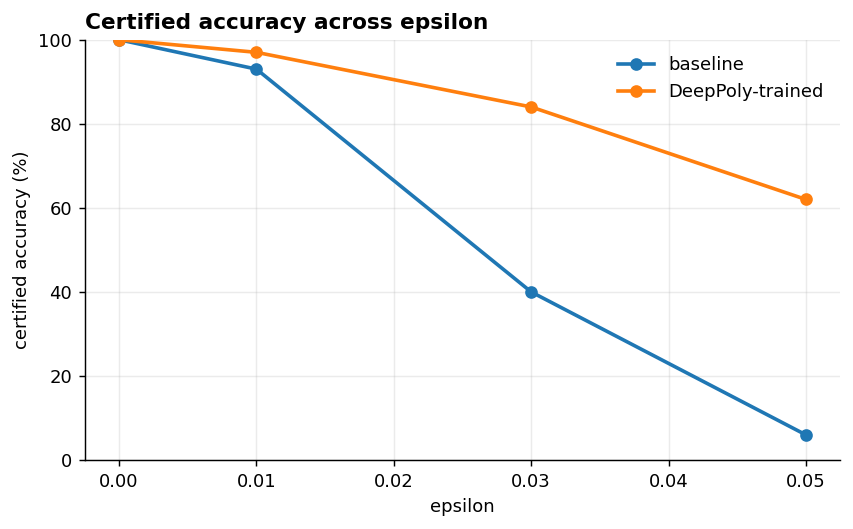

In [ ]:
baseline_eps_report = certification_report(baseline_model, X_test, y_test, EVAL_EPSILONS)
trained_eps_report = certification_report(robust_model, X_test, y_test, EVAL_EPSILONS)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(
    baseline_eps_report["epsilon"],
    100 * baseline_eps_report["certified_acc"],
    marker="o",
    linewidth=2,
    label="baseline",
)
ax.plot(
    trained_eps_report["epsilon"],
    100 * trained_eps_report["certified_acc"],
    marker="o",
    linewidth=2,
    label="DeepPoly-trained",
)
ax.set_title("Certified accuracy across epsilon", loc="left", fontweight="semibold")
ax.set_xlabel("epsilon")
ax.set_ylabel("certified accuracy (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False)
plt.show()


## 6. Limitations

This notebook is intended as a clear educational implementation, not a reproduction of the full DeepPoly paper results.

- The model is a small fully connected MNIST network.
- Certification is evaluated on `CERT_LIMIT` test images for runtime reasons.
- The perturbation model is `L_inf` pixel noise only.
- Certified accuracy is a formal guarantee for the specified epsilon, but only for this network, dataset, and perturbation model.
- Empirical attack accuracy and certified robustness are different metrics; this notebook focuses on certification.
